In [3]:
#installing libraries
import pandas as pd;
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# data importation

data = pd.read_csv("Dataset.csv");
print(data.head(5))

  show_id     type                             title         director  \
0      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1      s3  TV Show                         Ganglands  Julien Leclercq   
2      s6  TV Show                     Midnight Mass    Mike Flanagan   
3     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4      s8    Movie                           Sankofa     Haile Gerima   

         country date_added  release_year rating  duration  \
0  United States  9/25/2021          2020  PG-13    90 min   
1         France  9/24/2021          2021  TV-MA  1 Season   
2  United States  9/24/2021          2021  TV-MA  1 Season   
3         Brazil  9/22/2021          2021  TV-PG    91 min   
4  United States  9/24/2021          1993  TV-MA   125 min   

                                           listed_in  
0                                      Documentaries  
1  Crime TV Shows, International TV Shows, TV Act...  
2                 TV Dr

In [5]:
print(data.columns.tolist)
print("******************************")
print(data.describe)

<bound method IndexOpsMixin.tolist of Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')>
******************************
<bound method NDFrame.describe of      show_id     type                             title         director  \
0         s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
1         s3  TV Show                         Ganglands  Julien Leclercq   
2         s6  TV Show                     Midnight Mass    Mike Flanagan   
3        s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
4         s8    Movie                           Sankofa     Haile Gerima   
...      ...      ...                               ...              ...   
8785   s8797  TV Show                        Yunus Emre        Not Given   
8786   s8798  TV Show                         Zak Storm        Not Given   
8787   s8801  TV Show                Zindagi Gulzar Hai    

In [6]:
#missing value computation
print(data.isnull().sum())
print(data.columns.tolist())

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']


In [7]:
#combinin the relevant features for content-based recommmendations

In [8]:
def column_features(row):
    return f"{row['type']} {row['title']} {row['country']} {row['director']} {row['listed_in']}"
data['column_features'] = data.apply(column_features, axis=1)
print(data['column_features'].tolist())



['Movie Dick Johnson Is Dead United States Kirsten Johnson Documentaries', 'TV Show Ganglands France Julien Leclercq Crime TV Shows, International TV Shows, TV Action & Adventure', 'TV Show Midnight Mass United States Mike Flanagan TV Dramas, TV Horror, TV Mysteries', 'Movie Confessions of an Invisible Girl Brazil Bruno Garotti Children & Family Movies, Comedies', 'Movie Sankofa United States Haile Gerima Dramas, Independent Movies, International Movies', 'TV Show The Great British Baking Show United Kingdom Andy Devonshire British TV Shows, Reality TV', 'Movie The Starling United States Theodore Melfi Comedies, Dramas', 'Movie Motu Patlu in the Game of Zones India Suhas Kadav Children & Family Movies, Comedies, Music & Musicals', 'Movie Je Suis Karl Germany Christian Schwochow Dramas, International Movies', 'Movie Motu Patlu in Wonderland India Suhas Kadav Children & Family Movies, Music & Musicals', 'Movie Motu Patlu: Deep Sea Adventure India Suhas Kadav Children & Family Movies, Com

In [9]:
#converting text data into machine readable
#initalize the vectrorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data['column_features'])
print(tfidf_matrix)

  (np.int32(0), np.int32(8663))	0.06768019401779726
  (np.int32(0), np.int32(3406))	0.4046097204697604
  (np.int32(0), np.int32(6331))	0.6713291823137115
  (np.int32(0), np.int32(3158))	0.34333102828048145
  (np.int32(0), np.int32(13298))	0.0901415622199944
  (np.int32(0), np.int32(12197))	0.0993443548922107
  (np.int32(0), np.int32(6822))	0.4669138798775485
  (np.int32(0), np.int32(3518))	0.16476627726039658
  (np.int32(1), np.int32(13178))	0.44692175480587676
  (np.int32(1), np.int32(4663))	0.47820893044412793
  (np.int32(1), np.int32(4465))	0.23901500726377975
  (np.int32(1), np.int32(6412))	0.3869429885950307
  (np.int32(1), np.int32(7243))	0.44290244463490025
  (np.int32(1), np.int32(2929))	0.19936376192819596
  (np.int32(1), np.int32(11702))	0.2639482507559869
  (np.int32(1), np.int32(5971))	0.08973819823404017
  (np.int32(1), np.int32(234))	0.16020245006220918
  (np.int32(1), np.int32(285))	0.15946529548919175
  (np.int32(2), np.int32(13298))	0.09197143761512516
  (np.int32(2), 

In [10]:
#comouted similarities

similarity_score = cosine_similarity(tfidf_matrix,tfidf_matrix)
print(similarity_score)

[[1.         0.         0.0183601  ... 0.         0.         0.        ]
 [0.         1.         0.19898026 ... 0.29721161 0.17123067 0.16358945]
 [0.0183601  0.19898026 1.         ... 0.22437505 0.17058017 0.16296798]
 ...
 [0.         0.29721161 0.22437505 ... 1.         0.28241324 0.26981046]
 [0.         0.17123067 0.17058017 ... 0.28241324 1.         0.40445665]
 [0.         0.16358945 0.16296798 ... 0.26981046 0.40445665 1.        ]]


In [11]:
# recommendations

def get_recommendations(title, data, similarity_score, top_n=5):
    # 1. Check if title exists
    if title not in data['title'].values:
        return f"title {title} is not in the dataset, no recommendations can be generated."

    # 2. Get the integer index o
    index = data[data['title'] == title].index[0]

    # 3. Extract the row from your similarity matrix for this specific index 
    sim_score = list(enumerate(similarity_score[index]))
    
    # 4. Sort by the similarity values 
    sim_score = sorted(sim_score, key=lambda x: x[1], reverse=True)
    
    # 5. Get top matches 
    top_matches = sim_score[1:top_n + 1]

    # 6. Extract target indices and map back to your dataframe 
    movie_indices = [i[0] for i in top_matches]
    return data['title'].iloc[movie_indices].tolist()

# Test run
print(get_recommendations("The wolf", data, similarity_score))




title The wolf is not in the dataset, no recommendations can be generated.


In [12]:
print(data.columns.tolist())
print(data['country'].isnull().sum())
print(data['type'].isnull().sum())


['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'column_features']
0
0


In [13]:
#task 2 content type prediction model

x = data[['release_year','date_added','listed_in' ]]
print("relearse year:", data['release_year'].values)
y= data['type']


#encoding feature for (y)  and target (y)

from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split



#using lableEncoder for catergory variables

le = preprocessing.LabelEncoder();


y_encoded = le.fit_transform(y)

print(y_encoded)

print("categorical varaibles encoded")

X_train,X_test,Y_train,y_test = train_test_split(x,y_encoded,test_size=0.2,random_state=42)


preprocessor = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(),['release_year']),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False),['listed_in',])
    ]
)


X_train_processed= preprocessor.fit_transform(X_train)
X_test_processed= preprocessor.transform(X_test)


# 1. Print the raw value of the first item in your original data
print("--- BEFORE SCALING (Original Data) ---")
print(X_train['release_year'].iloc[0])

# 2. Print the first column of the processed matrix which holds 'release_year'
print("\n--- AFTER SCALING (Processed Matrix Row 0, Column 0) ---")
print(X_train_processed[0, 0])



relearse year: [2020 2021 2021 ... 2012 2016 2016]
[0 1 1 ... 1 1 1]
categorical varaibles encoded
--- BEFORE SCALING (Original Data) ---
2018

--- AFTER SCALING (Processed Matrix Row 0, Column 0) ---
0.42598313500669394


In [14]:
#model designing and evaluation


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#LogisticRegression model implementation
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_processed, Y_train)

#decisionTree model
decision_tree_model=  DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_processed,Y_train)


DecisionTreeClassifier(random_state=42)

In [15]:
#Evaluating the model accuracy, and prediction power


from sklearn.metrics import accuracy_score, classification_report

logistic_model_prediction = logistic_model.predict(X_test_processed)
decision_tree_prediction= decision_tree_model.predict(X_test_processed)




print("=" * 50)
print(f"LOGISTIC REGRESSION ACCURACY: :{accuracy_score(y_test,logistic_model_prediction):.2%}")
print(classification_report(y_test,logistic_model_prediction,target_names=['Movie', 'TV Show']))
print("*" * 50)


print("=" * 50)
print(f"Decision Tree Accuracy: :{accuracy_score(y_test,decision_tree_prediction):.2%}")
print(classification_report(y_test,decision_tree_prediction,target_names=['Movie', 'TV Show']))
print("*" * 50 )

LOGISTIC REGRESSION ACCURACY: :98.24%
              precision    recall  f1-score   support

       Movie       0.98      1.00      0.99      1238
     TV Show       1.00      0.94      0.97       520

    accuracy                           0.98      1758
   macro avg       0.99      0.97      0.98      1758
weighted avg       0.98      0.98      0.98      1758

**************************************************
Decision Tree Accuracy: :98.35%
              precision    recall  f1-score   support

       Movie       0.99      0.99      0.99      1238
     TV Show       0.97      0.97      0.97       520

    accuracy                           0.98      1758
   macro avg       0.98      0.98      0.98      1758
weighted avg       0.98      0.98      0.98      1758

**************************************************


In [16]:
#feature importance

categorical_encoder = preprocessor.named_transformers_['cat']
print("feature_in", categorical_encoder.feature_names_in_)
encoded_cat_names = categorical_encoder.get_feature_names_out(['listed_in'])
all_feature_names = ['release_year'] + list(encoded_cat_names)

#match with the importance

# match with the importance
importance = decision_tree_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance      # <-- Created with a CAPITAL 'I'
})

# FIXED: Changed 'importance' to 'Importance' to match the case exactly
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("=" * 40)
print("TOP 5 MOST IMPORTANT COLUMNS:")
print("=" * 40)
print(importance_df.head(5))




feature_in ['listed_in']
TOP 5 MOST IMPORTANT COLUMNS:
                                               Feature  Importance
401                                 listed_in_Kids' TV    0.057503
0                                         release_year    0.042419
391        listed_in_International TV Shows, TV Dramas    0.028981
231  listed_in_Crime TV Shows, International TV Sho...    0.023253
78      listed_in_Anime Series, International TV Shows    0.023156


### task 3 building Audience Rating Classfication

In [33]:
print(data.columns.tolist())

print(type(data['rating']))

print(data['column_features'].head(5))

['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'column_features']
<class 'pandas.core.series.Series'>
0    Movie Dick Johnson Is Dead United States Kirst...
1    TV Show Ganglands France Julien Leclercq Crime...
2    TV Show Midnight Mass United States Mike Flana...
3    Movie Confessions of an Invisible Girl Brazil ...
4    Movie Sankofa United States Haile Gerima Drama...
Name: column_features, dtype: object


In [38]:
X = data[['column_features', 'type', 'country']]
y= data['rating']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)



In [48]:
#encoding the categorical columns, and normalization 

preprocessing = ColumnTransformer(
    transformers=[
    ('text', TfidfVectorizer(stop_words='english',max_features=2500),'column_features'),
    ('cat', OneHotEncoder(handle_unknown='ignore'),['type', 'country','type'])
])

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression Pipeline": Pipeline([
        ('prep', preprocessing),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    "Random Forest Pipeline": Pipeline([
        ('prep', preprocessing),
        # FIXED: Corrected the tuple layout and fixed 'balanced' parameter typo
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])
}

results = {}

# --- Step 3 & 4: Train and Predict ---
for name, pipeline in models.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    results[name] = predictions

# --- Step 5: Evaluate Prediction Accuracy 
print("\n🔍 EVALUATION RESULTS:\n" + "="*30)
for name, preds in results.items():
    print(f"=== {name} Performance ===")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print("classfication report:",classification_report(y_test, preds, zero_division=0))
    print("\n" + "="*30 + "\n")

Training Logistic Regression Pipeline...
Training Random Forest Pipeline...

🔍 EVALUATION RESULTS:
=== Logistic Regression Pipeline Performance ===
Accuracy: 0.4577
classfication report:               precision    recall  f1-score   support

           G       0.08      0.20      0.12        10
       NC-17       0.00      0.00      0.00         1
          NR       0.04      0.20      0.07        20
          PG       0.41      0.56      0.47        72
       PG-13       0.36      0.58      0.45       123
           R       0.44      0.62      0.51       200
       TV-14       0.51      0.50      0.50       539
        TV-G       0.16      0.31      0.21        55
       TV-MA       0.70      0.41      0.52       801
       TV-PG       0.22      0.24      0.23       215
        TV-Y       0.66      0.69      0.68        77
       TV-Y7       0.60      0.59      0.60        83
    TV-Y7-FV       0.00      0.00      0.00         1
          UR       0.00      0.00      0.00         1

 

## model optimization


In [51]:
from sklearn.model_selection import GridSearchCV

param_grid={
    "clf__C": [0.1,1.0,10.0],
    'clf__solver': ['lbfgs', 'saga']
}

print("Optimization Logistics Regression...")

grid_search = GridSearchCV(models['Logistic Regression Pipeline'],param_grid)
grid_search.fit(X_train,y_train)


print(f"Best Parameters: {grid_search.best_params_}")
print(f"Optimized Macro F1-Score:{grid_search.best_score_:.4f}")

Optimization Logistics Regression...


/Users/drreasons/Desktop/auspify/.venv/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/drreasons/Desktop/auspify/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/drreasons/Desktop/auspify/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/drreasons/Desktop/auspify/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/drreasons/Desktop/auspify/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not 

Best Parameters: {'clf__C': 10.0, 'clf__solver': 'lbfgs'}
Optimized Macro F1-Score:0.4759


Matplotlib is building the font cache; this may take a moment.


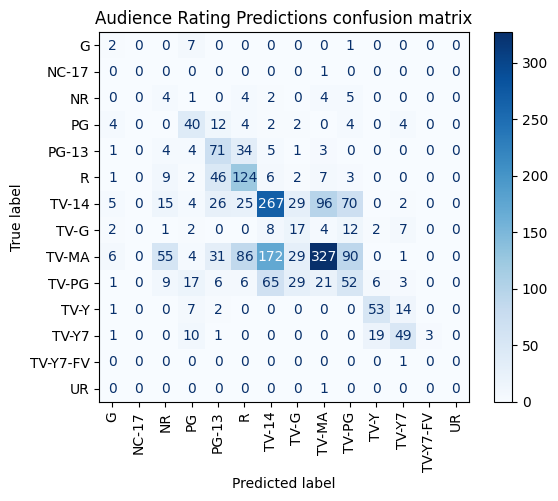

In [52]:
import matplotlib.pyplot as plt


from sklearn.metrics import ConfusionMatrixDisplay

best_model = models['Logistic Regression Pipeline']


ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    xticks_rotation='vertical'
)

plt.title("Audience Rating Predictions confusion matrix")

plt.show()

In [53]:
def predict_audience_rating(content_type, country, features_text):
    # Construct a mini DataFrame matching the training structure
    input_data = pd.DataFrame([{
        'type': content_type,
        'country': country,
        'column_features': features_text
    }])
    
    # Use your trained pipeline to predict
    prediction = models["Logistic Regression Pipeline"].predict(input_data)[0]
    return f"Estimated Audience Rating: {prediction}"

# Try testing it!
print(predict_audience_rating("Movie", "United States", "A dark psychological thriller following a gritty detective solving crimes."))


Estimated Audience Rating: R
